In [2]:
#Importing relevent packages
import sys; print(sys.executable)
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta

/nethome/6903894/parcels_env/bin/python


In [3]:
#RATES
maximum_growth_rate = 0.095 #doublings/day
mortality_rate = 0.025      #relative loss/day

#Minimum, maximum and optimal temperature 
T_min = 20      #degC
T_max = 31      #degC
T_opt = 27.5    #degC

#Nitrogen half saturation constant
k_N  = 0.000129 #mmol/m3
k_N2  = 0.001 #mmol/m3
k_N3 = 0.01 #mmol/m3

#Optimal salinity
S_opt = 36 #psu

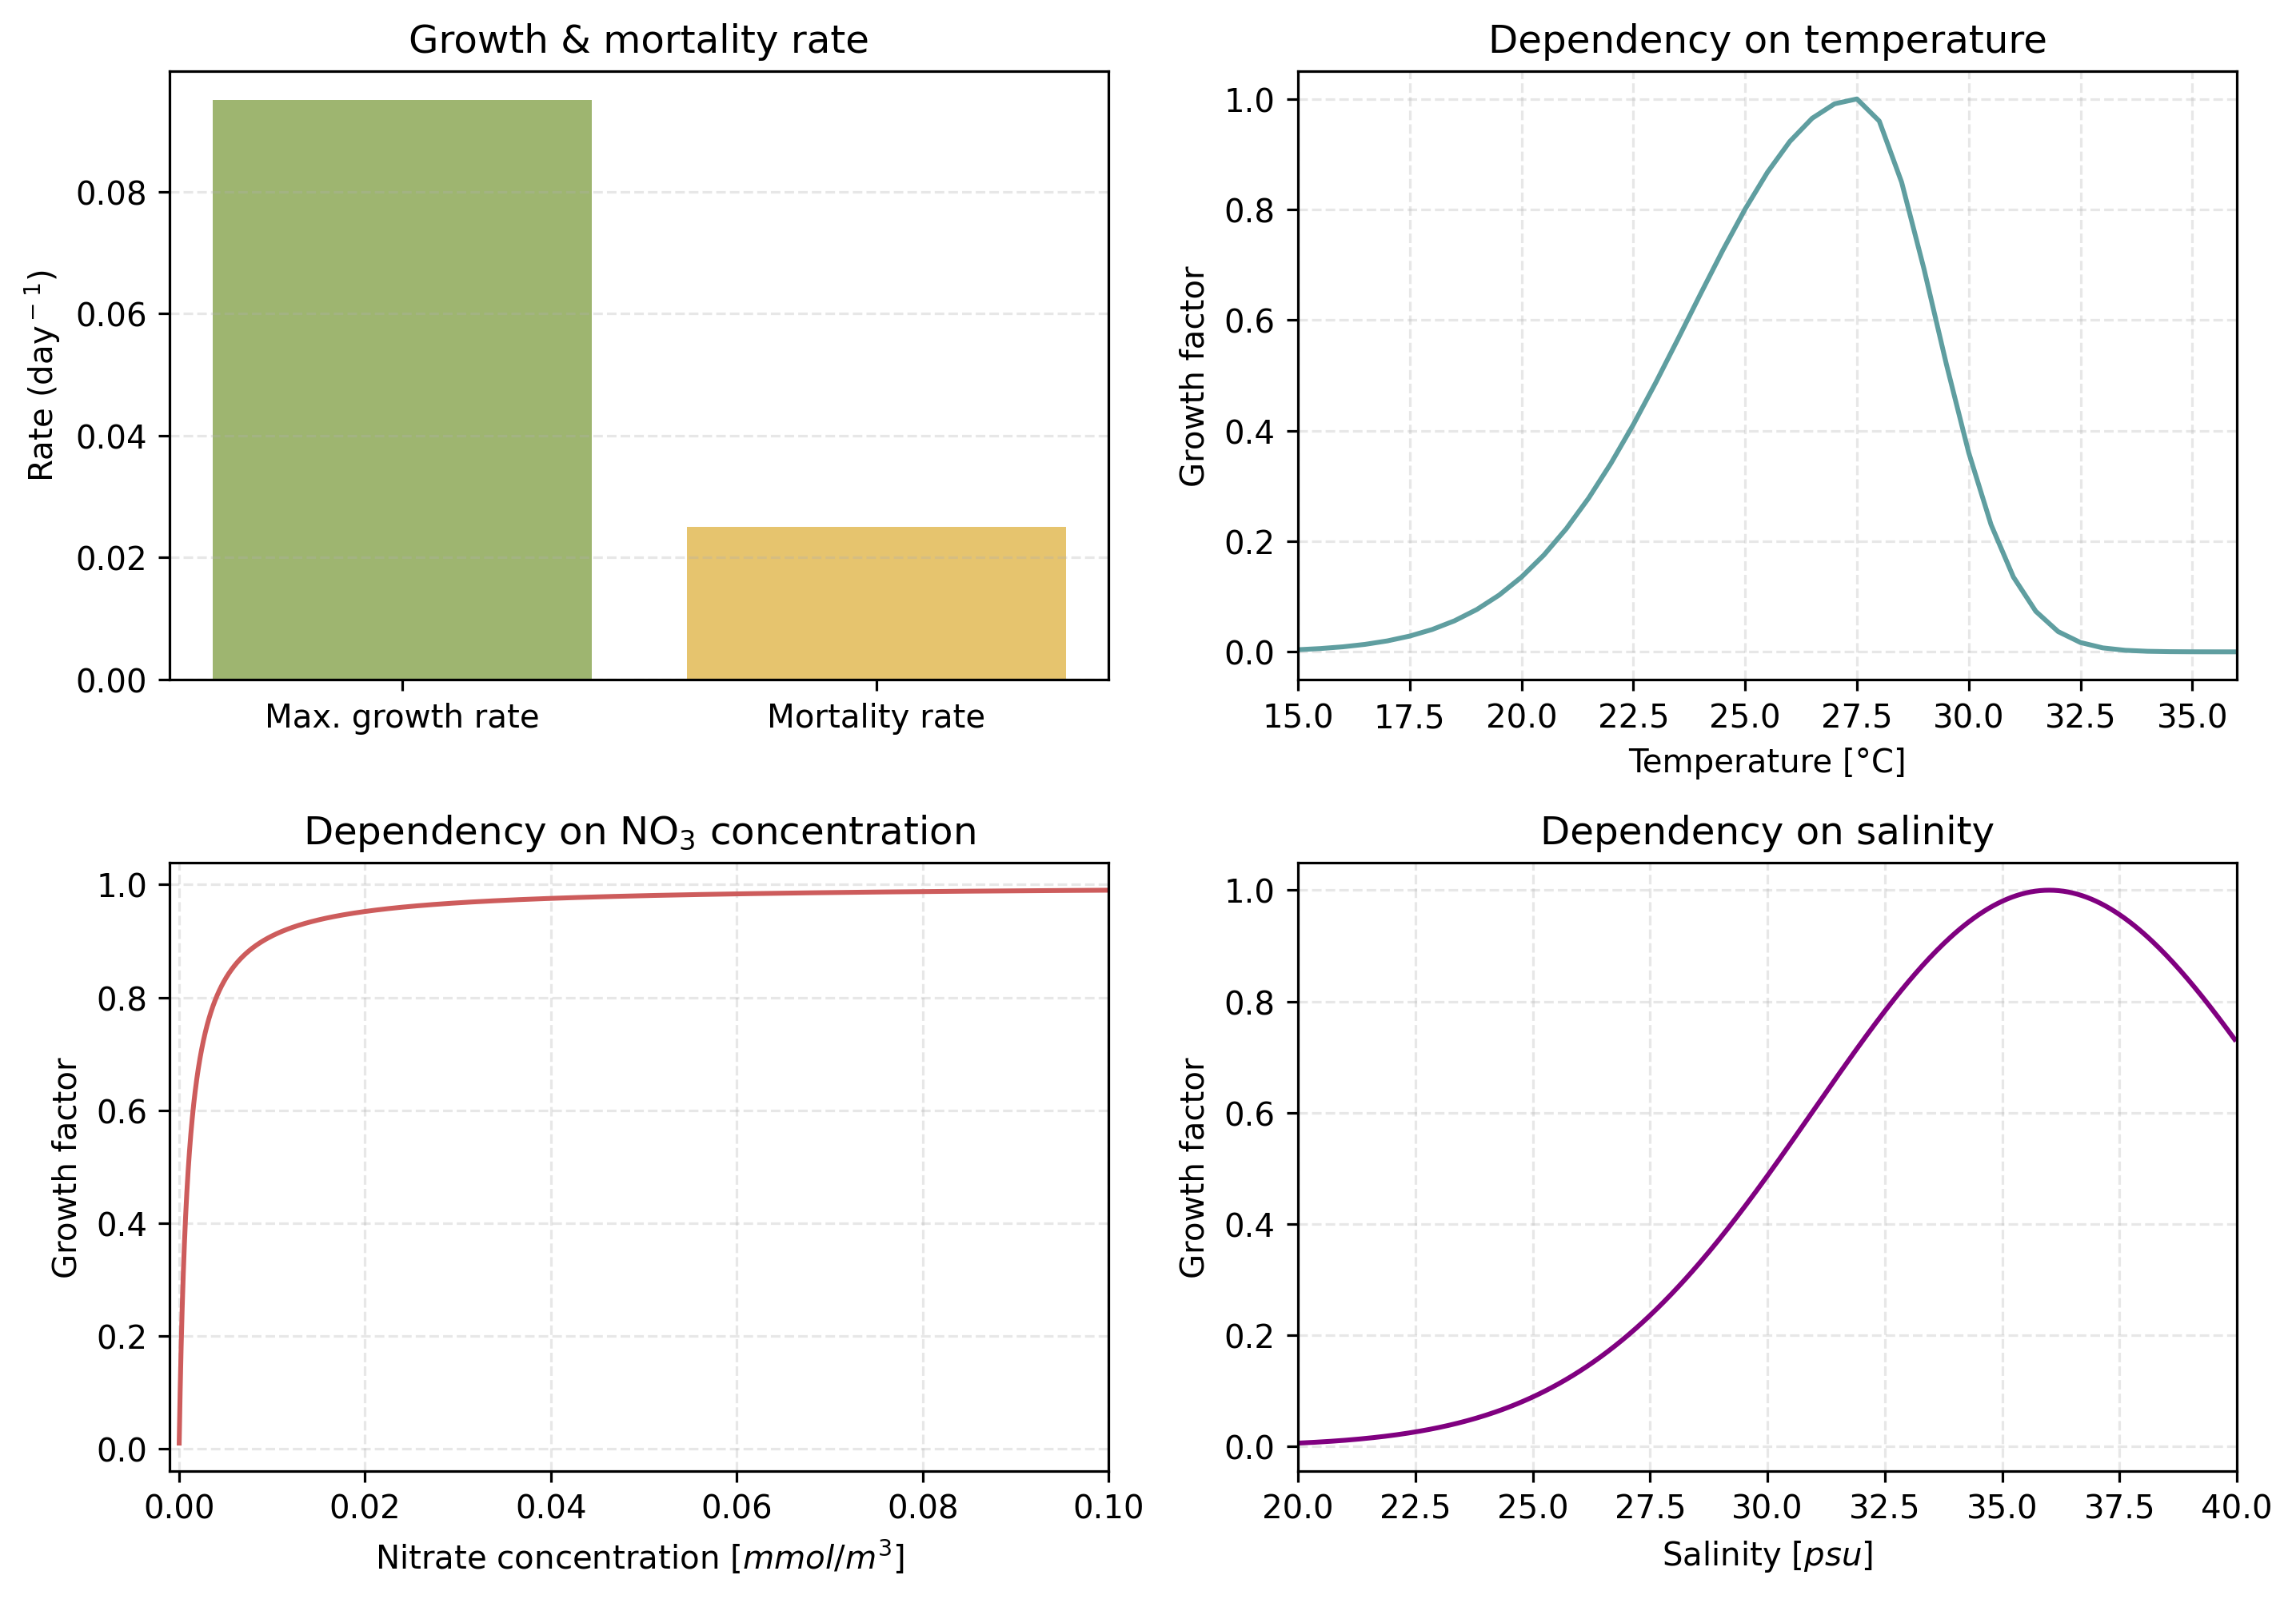

In [4]:
#Variable initialization
T = np.arange(14,38,0.5)
N = np.arange(0.00001,0.1,0.00001)
S = np.arange(20,40,0.05)

#Growth factor curves
T_x = np.full_like(T,T_min)    
T_x[T > T_opt] = T_max          
growth_factor_T = np.exp(-2 * ((T - T_opt) /(T_x - T_opt))**2 )
growth_factor_N = N / (N + k_N )
growth_factor_N2 = N / (N + k_N2)
growth_factor_N3 = N / (N + k_N3)
growth_factor_S = np.exp(-0.02 * (S_opt - S)**2)

#Figure
fig_growthcurves, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 7),dpi=290)

#Growth rate & mortality rate
rates = [maximum_growth_rate, mortality_rate]
labels = ['Max. growth rate', 'Mortality rate']
ax1.bar(labels, rates, color=['olivedrab', 'goldenrod'], alpha=0.65)
ax1.set_ylabel(f'Rate (day$^-$$^1$)')
ax1.set_title('Growth & mortality rate')
ax1.grid(alpha=0.3, linestyle='--', axis='y')


#Temperature
ax2.plot(T, growth_factor_T, label=f'Jouanno et al. (2025)', c = 'cadetblue')
ax2.set_xlabel('Temperature [°C]')
ax2.set_ylabel('Growth factor')
ax2.set_title('Dependency on temperature')
ax2.grid(alpha=0.3, linestyle='--')
#ax2.legend(loc='upper left')
ax2.set_xlim(15,36)

#Nitrogen concentration
#ax3.plot(N, growth_factor_N, label = f'Monod equation with k$_N$ = {k_N}', color='tab:brown')
ax3.plot(N, growth_factor_N2, label = f'Monod equation with k$_N$= {k_N2}', color='indianred')
#ax3.plot(N, growth_factor_N3, label = f'Monod equation with k$_N$ = {k_N3}', color='darkorange')
ax3.set_xlabel('Nitrate concentration [$mmol / m^3$]')
ax3.set_ylabel('Growth factor')
ax3.set_title(f'Dependency on NO$_3$ concentration')
ax3.grid(alpha=0.3, linestyle='--')
#ax3.legend(loc='lower right')
ax3.set_xlim(-0.001,0.1)

#Salinity concentration
ax4.plot(S, growth_factor_S, label = f' Jouanno et al. (2025)', color='purple')
ax4.set_xlabel('Salinity [$psu$]')
ax4.set_ylabel('Growth factor')
ax4.set_title(f'Dependency on salinity' )
ax4.grid(alpha=0.3, linestyle='--')
#ax4.legend()
ax4.set_xlim(20,40)

plt.tight_layout()
plt.savefig("THESIS_PLOTS/dependencies_nolegend.pdf", format="pdf", bbox_inches="tight")
plt.savefig("THESIS_PLOTS/dependencies_nolegend.png", format="png", bbox_inches="tight")
plt.show()

In [8]:
#TEMPERATURE LIMITATION
#Initializing temperature array in deg Celsius
T = np.arange(12,41,0.5)

#Model parameters based on Jouanno et al. (2021) in deg Celsius
T_opt_J = 26
Tmin_J = 10.5
Tmax_J = 43.8
Tx = np.full_like(T,Tmin_J)  #Tx describes lower limit or upper limit under/above which there is no growth
Tx[T > T_opt_J] = Tmax_J

#Model parameters based on Podlejski et al. (2024) in deg Celsius
T_opt_P = 27.5
Tmin_P = 24
Tmax_P = 28
Tref = np.full_like(T,Tmin_P)  #Tref describes lower limit or upper limit under/above which there is no growth
Tref[T > T_opt_P] = Tmax_P

#Model parameters based on Bonner et al. (2024) in deg Celsius
Tmin_B = 10
Tmax_B = 40
T_opt_B = (Tmin_B + Tmax_B) / 2 
Tx_B = np.full_like(T,Tmin_B)  #Tx describes lower limit or upper limit under/above which there is no growth
Tx_B[T > T_opt_B] = Tmax_B

#Model parameters based on Jouanno et al. (2025) in deg Celsius
Tmin_J25 = 20
Tmax_J25 = 31
T_opt_J25 = 27.5 
Tx25 = np.full_like(T,Tmin_J25)  #Tx describes lower limit or upper limit under/above which there is no growth
Tx25[T > T_opt_J25] = Tmax_J25

#Model parameters ADAPTED in deg Celsius
Tmin_a = 18
Tmax_a = 33
T_opt_a = 27.5 
Txa = np.full_like(T,Tmin_a)  #Tx describes lower limit or upper limit under/above which there is no growth
Txa[T > T_opt_a] = Tmax_a

#Growth limitation dependent on temperature, formula from Jouanno et al. (2021) and (2025)
growth_limitation_T_J = np.exp(-0.5 * ( (T - T_opt_J)/ (Tx - T))**2 )
growth_limitation_T_J25 = np.exp(-2 * ( (T - T_opt_J25)/ (Tx25 - T_opt_J25))**2 )

#Growth limitation dependent on temperature, formula from Podlejski et al. (2024).
growth_limitation_T_P = np.exp(-2 * ((T - T_opt_P)/ (Tref - T))**2 )

#Growth limitation dependent on temperature, formula from Bonner et al. (2024).
growth_limitation_T_B = np.exp(-0.5 * ( (T - T_opt_B)/ (Tx - T))**2 )

#Growth limitation dependent on temperature, adapted!
growth_limitation_T_a = np.exp(-2 * ( (T - T_opt_a)/ (Txa - T_opt_a))**2 )

#LIGHT LIMITATION
#Initializing incoming sunlight array in W/m2
I = np.arange(0,301,1)

#Optimal light intensity, from Jouanno et al. (2021), possible range from 60-80
I_opt_J = 62.3 #W/m2
I_opt_J25 = 180
#Optimal light intensity and minimum irradiance value, from Podlejski et al. (2024)
I_opt_P = 170 #W/m2
I_min_P = 30

#Growth limitation dependent on incoming irradiance, formula from Jouanno et al. (2021).
growth_limitation_I_J = 1 / ( 1 + np.exp(-0.1 * I / I_opt_J))
growth_limitation_I_J25 = 1 / ( 1 + np.exp(-0.1*0.41*(I-I_opt_J25)))

#Growth limitation dependent on incoming irriadiance, formula from Podlejski et al. (2024).
growth_limitation_I_P = ((I - I_min_P)/I_opt_P) * np.exp( 1 - ((I - I_min_P)/I_opt_P) )

/tmp/ipykernel_7228/1253622111.py:45: RuntimeWarning: divide by zero encountered in divide
  growth_limitation_T_P = np.exp(-2 * ((T - T_opt_P)/ (Tref - T))**2 )


In [5]:
#Experimental data from Magaña-Gallegos et al. (2023)
#Relative Growth Rates - RGR [doubling day-1]
fluitans = [0.078, 0.077, 0.095, 0.058]
natansI = [0.057, 0.067, 0.063, 0.054]
natansVIII = [0.058, 0.059, 0.053, 0.045]

#Corresponding temperatures
temp_exp = [22, 25, 28, 31]

growth_limitation_T_nviii = np.max(natansVIII) * np.exp(-0.5 * ( (T - T_opt_J)/ (T - Tx_B))**2 )

/tmp/ipykernel_85296/886624579.py:10: RuntimeWarning: divide by zero encountered in divide
  growth_limitation_T_nviii = np.max(natansVIII) * np.exp(-0.5 * ( (T - T_opt_J)/ (T - Tx_B))**2 )


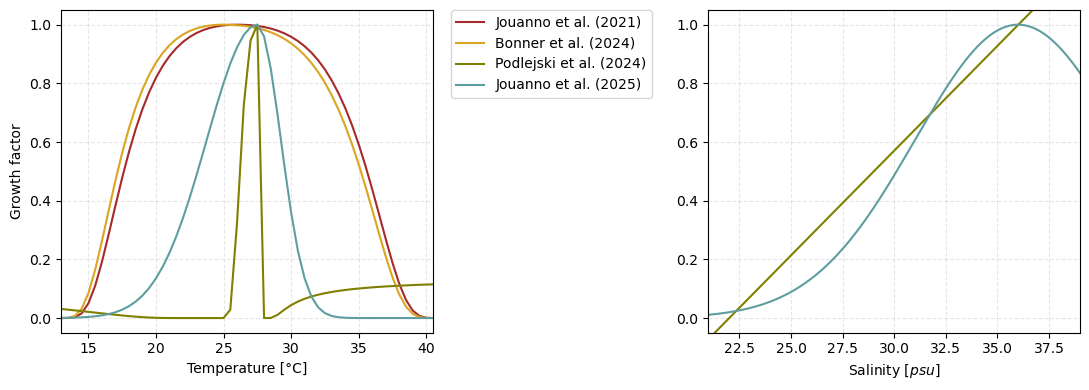

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi = 100)

#Temperature
ax1.plot(T, growth_limitation_T_J, label='Jouanno et al. (2021)', c = 'brown')
ax1.plot(T, growth_limitation_T_B, label='Bonner et al. (2024)', c = 'goldenrod')
ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)', c = 'olive')
ax1.plot(T, growth_limitation_T_J25, label='Jouanno et al. (2025)', c = 'cadetblue')
ax1.set_xlabel('Temperature [°C]')
ax1.set_ylabel('Growth factor')
#ax1.set_title('Dependencies on temperature')
ax1.grid(alpha=0.3, linestyle='--')
ax1.legend(bbox_to_anchor=(1.59, 1),
                         loc='upper right', borderaxespad=0.)
ax1.set_xlim(13,40.5)
ax1.set_ylim(-0.05,1.05)

#Temperature
ax2.plot(S, 0.0714 * S - 1.5714, label = f' Podlejski et al. (2024)', color='olive')
ax2.plot(S, growth_factor_S, label = f' Jouanno et al. (2025)', color='cadetblue')
ax2.set_xlabel('Salinity [$psu$]')
#ax2.set_ylabel('Growth factor')
#ax2.set_title('Dependency on temperature')
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_ylim(-0.05,1.05)
ax2.set_xlim(21,39)

plt.tight_layout()
plt.savefig("THESIS_PLOTS/temp_sal_dependencies.pdf", format="pdf", bbox_inches="tight")
plt.savefig("THESIS_PLOTS/temp_sal_dependencies.png", format="png", bbox_inches="tight")
plt.show()

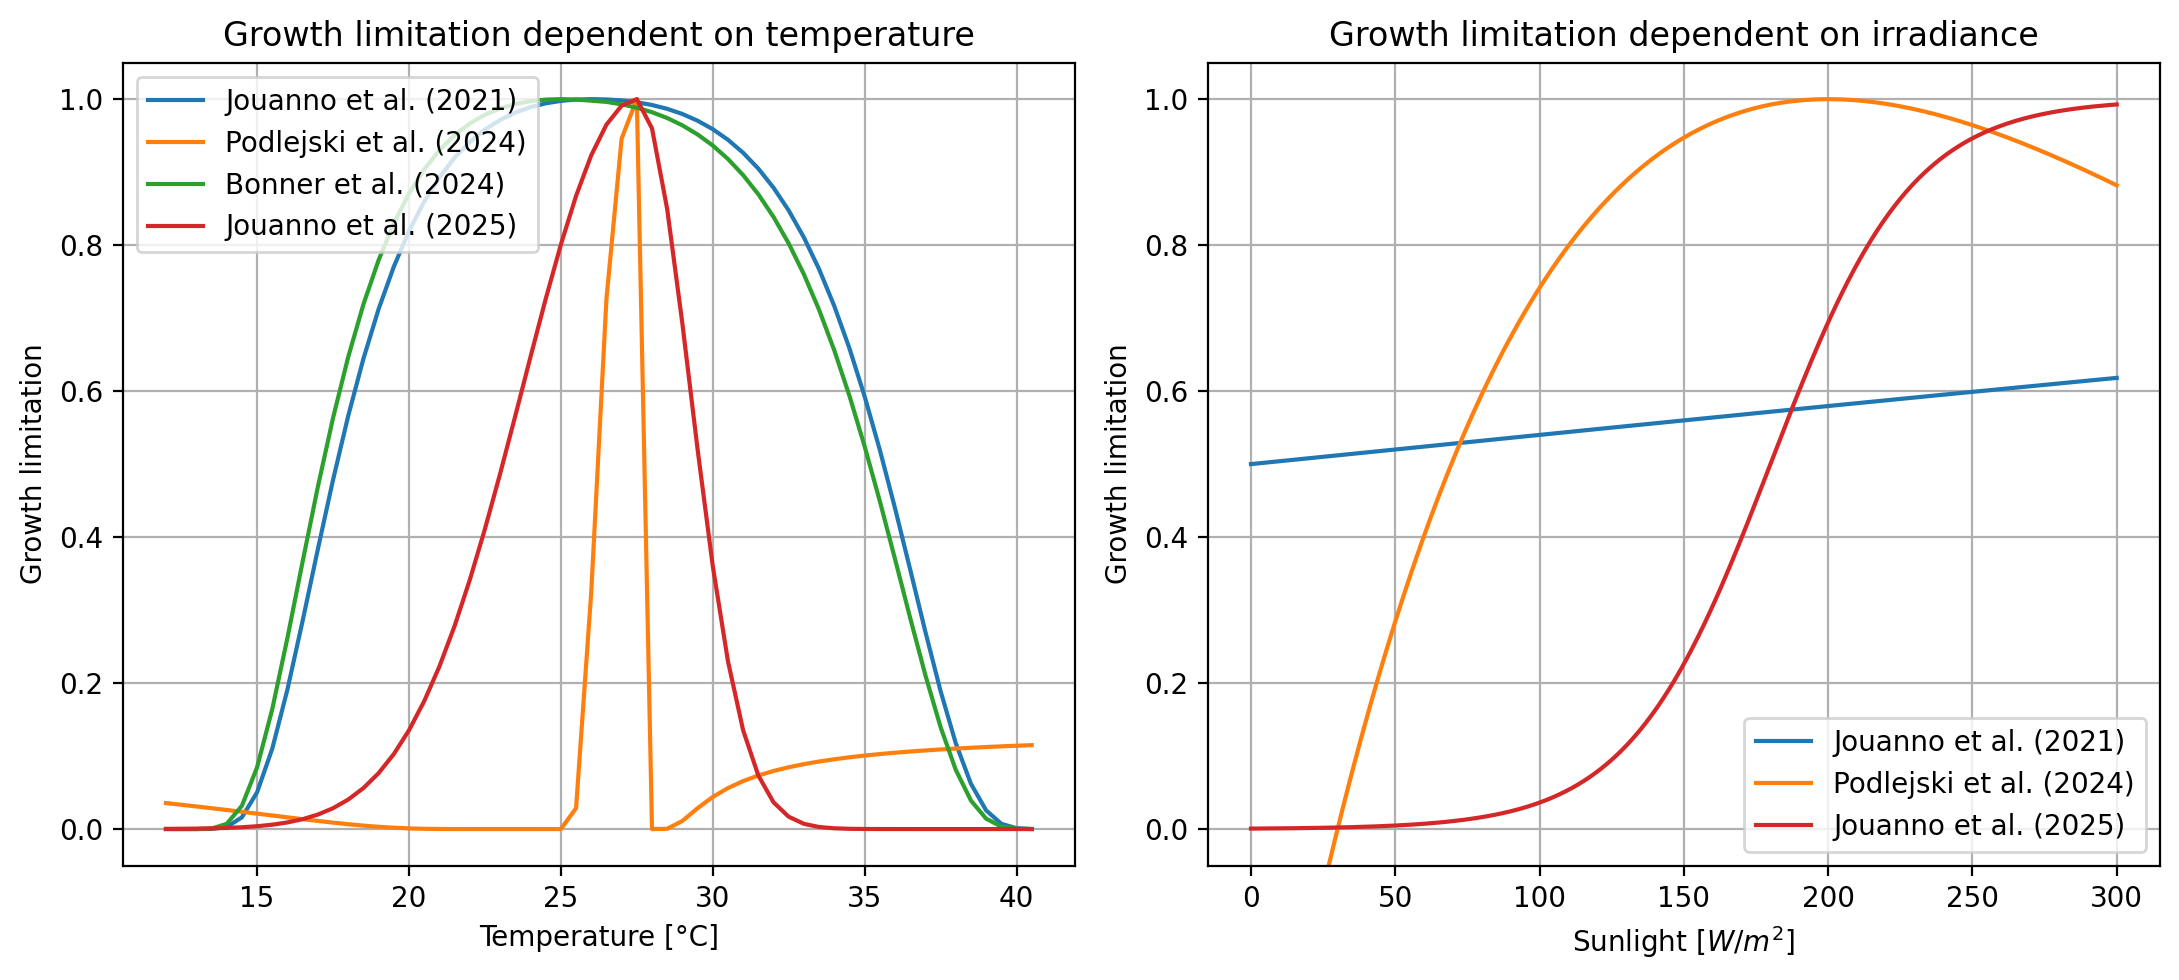

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi = 200)

#Temperature
ax1.plot(T, growth_limitation_T_J, label='Jouanno et al. (2021)')
ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)')
ax1.plot(T, growth_limitation_T_B, label='Bonner et al. (2024)')
ax1.plot(T, growth_limitation_T_J25, label='Jouanno et al. (2025)')
ax1.set_xlabel('Temperature [°C]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation dependent on temperature')
ax1.grid()
ax1.legend(loc='upper left')

#Sunlight
ax2.plot(I, growth_limitation_I_J, label = 'Jouanno et al. (2021)')
ax2.plot(I, growth_limitation_I_P, label = 'Podlejski et al. (2024)')
ax2.plot(I, growth_limitation_I_J25, label = 'Jouanno et al. (2025)', c = 'tab:red')
ax2.set_xlabel('Sunlight [$W/m^2$]')
ax2.set_ylabel('Growth limitation')
ax2.set_title('Growth limitation dependent on irradiance')
ax2.legend()
ax2.set_ylim(-0.05,1.05)
ax2.grid()

plt.tight_layout()
plt.show()

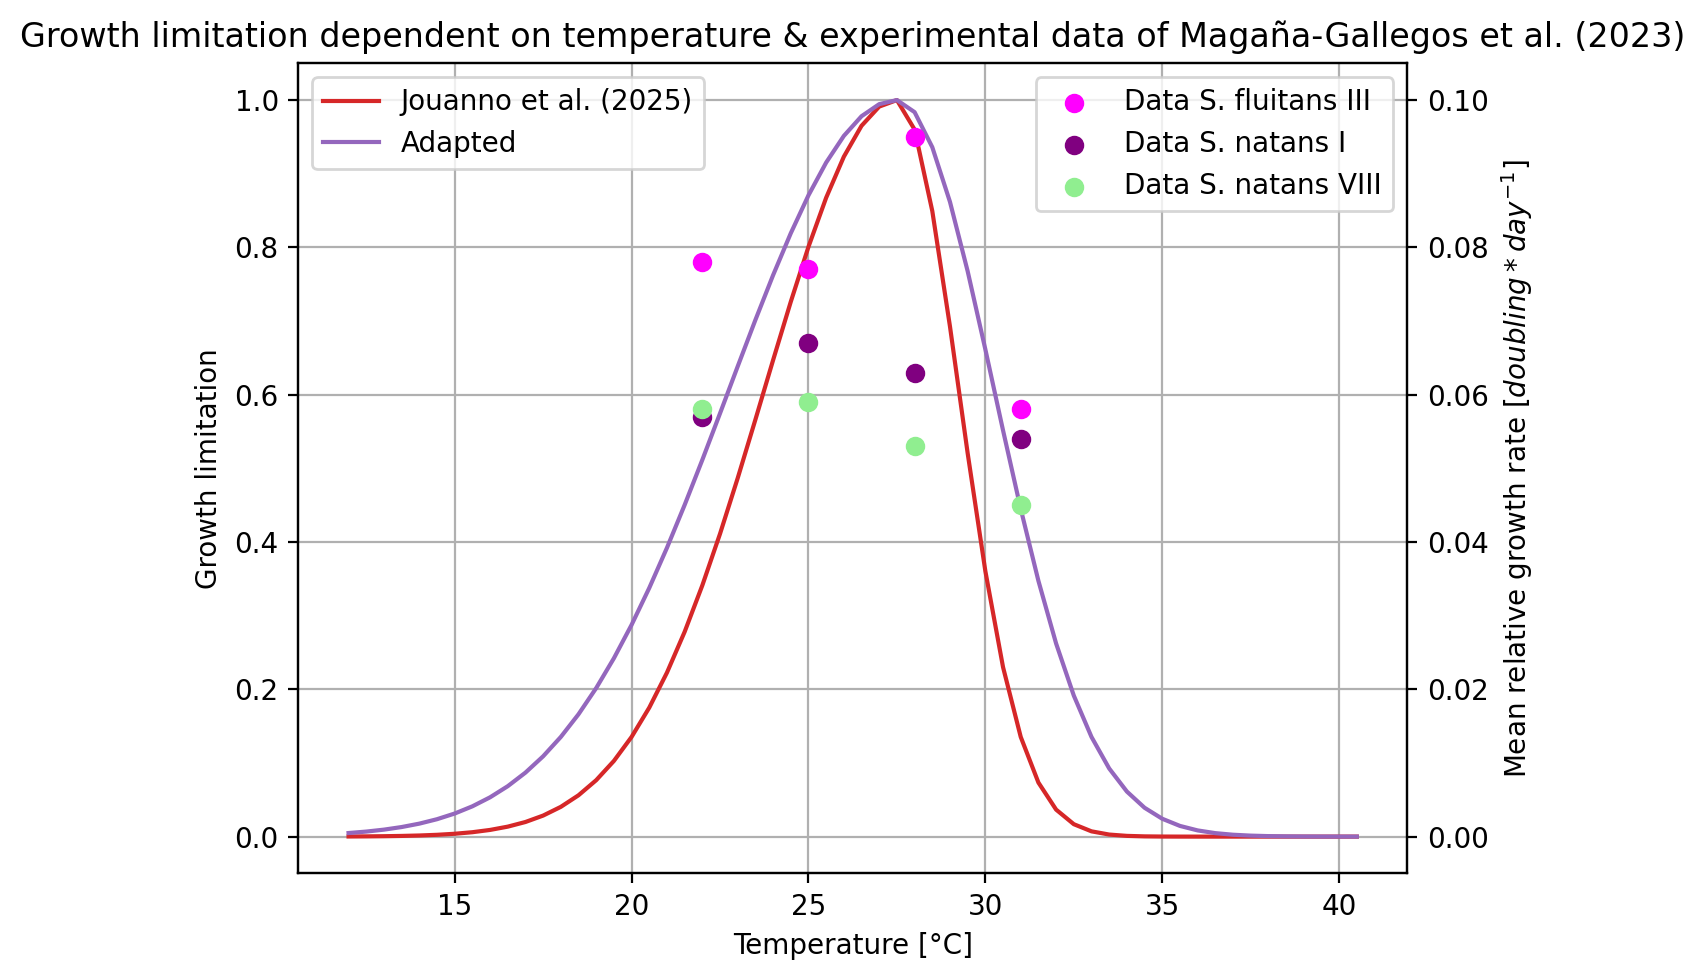

In [6]:
fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5), dpi = 200)

#Temperature
#ax1.plot(T, growth_limitation_T_J, label='Jouanno et al. (2021)')
#ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)')
#ax1.plot(T, growth_limitation_T_B, label='Bonner et al. (2024)')
ax1.plot(T, growth_limitation_T_J25, label='Jouanno et al. (2025)', c='tab:red')
ax1.plot(T, growth_limitation_T_a, label='Adapted', c='tab:purple')
ax1.set_xlabel('Temperature [°C]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation dependent on temperature & experimental data of Magaña-Gallegos et al. (2023)')
ax1.set_ylim(-0.05,1.05)
ax1.grid()

# Temperature - Secondary axis for experimental data
ax1b = ax1.twinx()
#ax1b.plot(T,growth_limitation_T_nviii, color='lightblue')
ax1b.scatter(temp_exp, fluitans, color='magenta', label='Data S. fluitans III', zorder=5)
ax1b.scatter(temp_exp, natansI, color='purple', label='Data S. natans I', zorder=5)
ax1b.scatter(temp_exp, natansVIII, color='lightgreen', label='Data S. natans VIII', zorder=5)
ax1b.set_ylabel('Mean relative growth rate [$doubling * day^{-1}$]')
# Optional: Match y limits if needed
ax1b.set_ylim(-0.005,0.105)

ax1.legend(loc='upper left')
ax1b.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
#NUTRIETN LIMITATION
#Initializing nitrogen array in ....
Q_N = np.arange(0.024,0.1,0.0005)

N_conc = np.arange(0,1,0.00002)

print(Q_N)

#Model parameters based on Jouanno et al. (2021) in mg N / mg C
Q_N_min = 0.027
Q_N_max = 0.034
#Model parameters based on Jouanno et al. (2025) in mg N / mg C
Q_N_min_25 = 0.05
Q_N_max_25 = 0.08

#Sargassum nitrogen uptake half saturation according to Bonner et al
k_n_B  = 0.000129 #mmol/ m3

growth_limitation_nitrogen_B = 1 / (1+ k_n_B / N_conc)

#Growth limitation dependent on nitrogen availability, formula from Jouanno et al. (2021).
growth_limitation_nitrogen_J21 = ( ( 1- Q_N_min / Q_N ) / ( 1 - Q_N_min / Q_N_max) )

#Growth limitation dependent on nitrogen availability, formula from Jouanno et al. (2021).
growth_limitation_nitrogen_J25 = ( ( 1- Q_N_min_25 / Q_N ) / ( 1 - Q_N_min_25 / Q_N_max_25) )


#SALINITY LIMITATION
#Initializing salinity array in 
S_ = np.arange(20,40,0.05)
#Growth limitation dependent on nitrogen availability, formula from Jouanno et al. (2025).
growth_limitation_salinityJ = np.exp(-0.02 * (36-S_)**2)
growth_limitation_salinityP = 0.0714 * S_ - 1.5714

#CARBON CONTENT LIMITATION (SARGASSUM DENSITY LIMITATION)
C_conc = np.arange(0.000001,0.0001, 0.0000001)
K_c = 0.0002 #mg C / m2
#Growth limitation dependent on carbon content, formula from Jouanno et al. (2025)
growth_limitation_C_J25 = 1 - (C_conc / (K_c + C_conc))

[0.024  0.0245 0.025  0.0255 0.026  0.0265 0.027  0.0275 0.028  0.0285
 0.029  0.0295 0.03   0.0305 0.031  0.0315 0.032  0.0325 0.033  0.0335
 0.034  0.0345 0.035  0.0355 0.036  0.0365 0.037  0.0375 0.038  0.0385
 0.039  0.0395 0.04   0.0405 0.041  0.0415 0.042  0.0425 0.043  0.0435
 0.044  0.0445 0.045  0.0455 0.046  0.0465 0.047  0.0475 0.048  0.0485
 0.049  0.0495 0.05   0.0505 0.051  0.0515 0.052  0.0525 0.053  0.0535
 0.054  0.0545 0.055  0.0555 0.056  0.0565 0.057  0.0575 0.058  0.0585
 0.059  0.0595 0.06   0.0605 0.061  0.0615 0.062  0.0625 0.063  0.0635
 0.064  0.0645 0.065  0.0655 0.066  0.0665 0.067  0.0675 0.068  0.0685
 0.069  0.0695 0.07   0.0705 0.071  0.0715 0.072  0.0725 0.073  0.0735
 0.074  0.0745 0.075  0.0755 0.076  0.0765 0.077  0.0775 0.078  0.0785
 0.079  0.0795 0.08   0.0805 0.081  0.0815 0.082  0.0825 0.083  0.0835
 0.084  0.0845 0.085  0.0855 0.086  0.0865 0.087  0.0875 0.088  0.0885
 0.089  0.0895 0.09   0.0905 0.091  0.0915 0.092  0.0925 0.093  0.0935
 0.094

/tmp/ipykernel_48504/944026361.py:19: RuntimeWarning: divide by zero encountered in divide
  growth_limitation_nitrogen_B = 1 / (1+ k_n_B / N_conc)


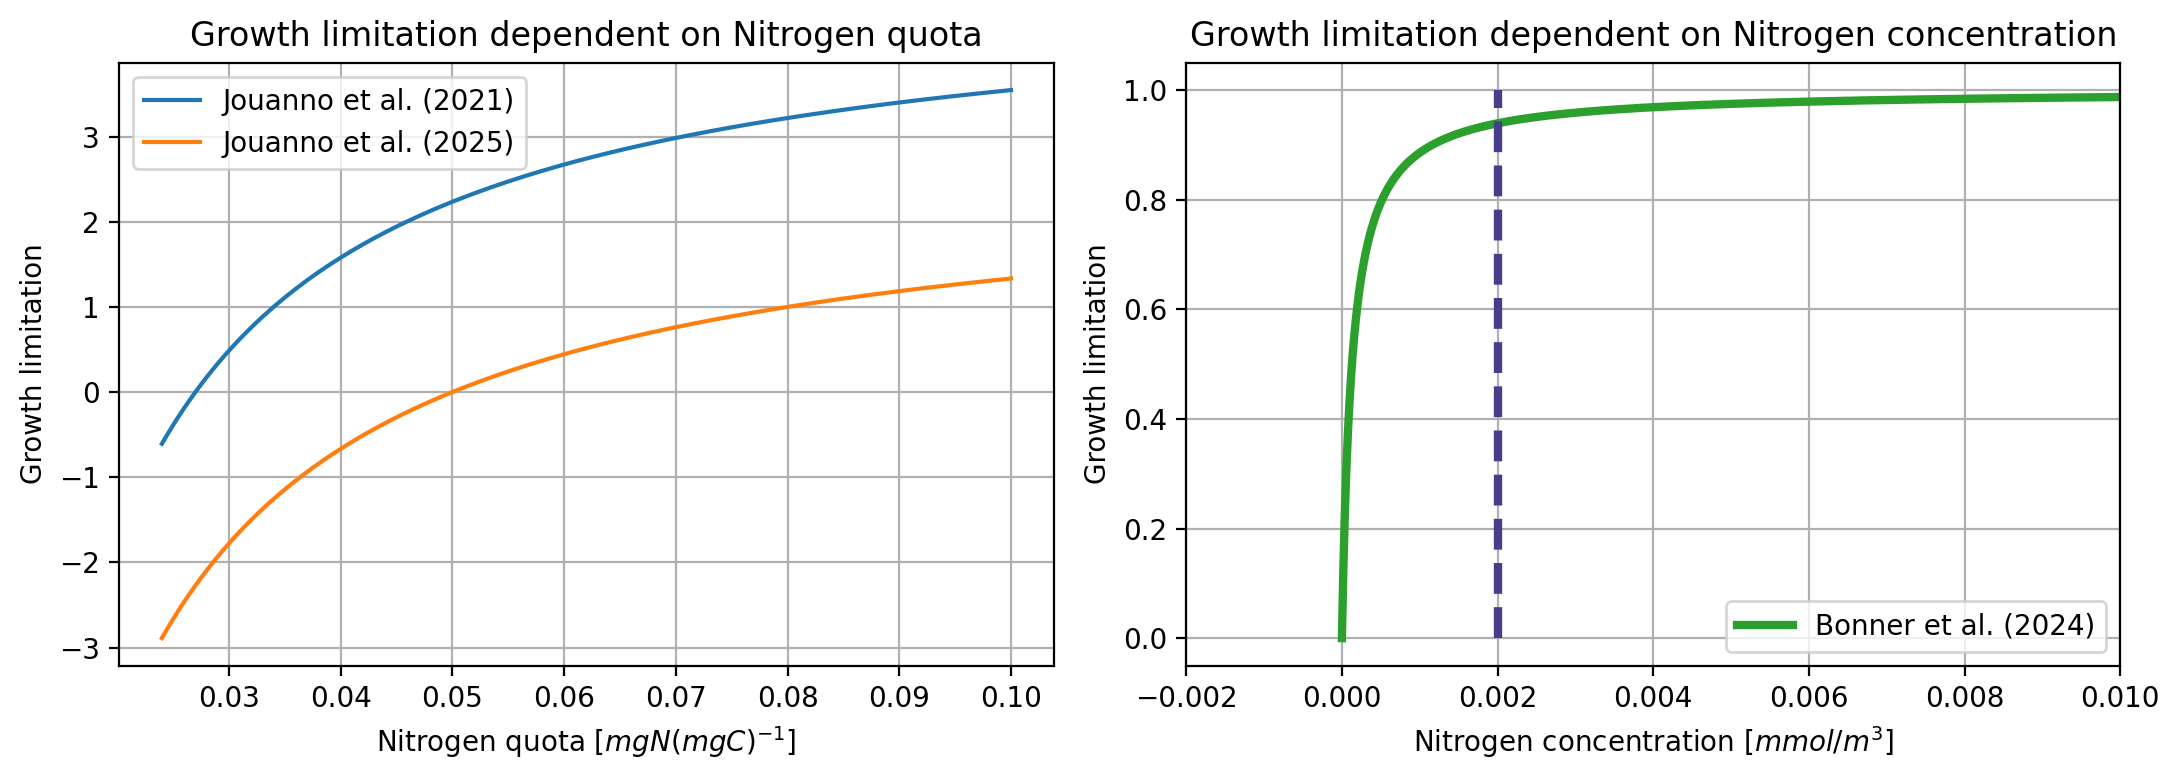

In [6]:
fignutrients, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi = 200)

#Nitrogen quota
ax1.plot(Q_N, growth_limitation_nitrogen_J21, label='Jouanno et al. (2021)')
ax1.plot(Q_N, growth_limitation_nitrogen_J25, label='Jouanno et al. (2025)')
#ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)')
ax1.set_xlabel('Nitrogen quota [$mg N (mg C)^{-1}$]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation dependent on Nitrogen quota')
ax1.grid()
ax1.legend(loc='upper left')

#Nitrogen concentration
ax2.plot(N_conc, growth_limitation_nitrogen_B, label = 'Bonner et al. (2024)', linewidth = 3, color='tab:green')
ax2.set_xlabel('Nitrogen concentration [$mmol / m^3$]')
ax2.set_ylabel('Growth limitation')
ax2.set_title('Growth limitation dependent on Nitrogen concentration')
ax2.legend()
ax2.set_xlim(-0.002,0.01)
ax2.vlines(0.002, 0,1, linestyles='dashed', linewidth = 3,  color='darkslateblue')
ax2.grid()

plt.tight_layout()
plt.show()

In [58]:
T = np.arange(14,38,0.5)
N = np.arange(0.00001,0.05,0.00001)
S = np.arange(20,40,0.05)

#TEMPERATURE
T_min = 20  #degC
T_max = 31  #degC
T_opt = 27.5   #degC
T_x = np.full_like(T,T_min)    #degC
T_x[T > T_opt] = T_max   #degC
growth_factor_T = np.exp(-2 * ((T - T_opt) /(T_x - T_opt))**2 )

#NITROGEN
k_N  = 0.000129 #mmol/ m3
k_N2  = 0.00129 #mmol/ m3
growth_factor_N = 1 / (1+ k_N / N)
growth_factor_N2 = 1 / (1+ k_N2 / N)

#SALINITY
S_opt = 36 #psu
growth_factor_S = np.exp(-0.02 * (S_opt - S)**2)

#RATES
RGR = 0.095
RMR = 0.025
rates = [RGR, RMR]
labels = ['Max. growth rate', 'Mortality rate']

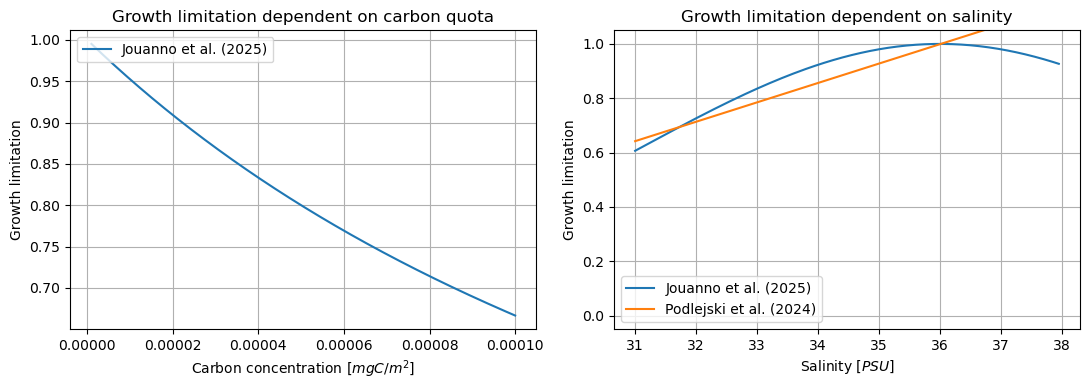

In [13]:
figlim3, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

#Temperature
#ax1.plot(Q_N, growth_limitation_nitrogen_J21, label='Jouanno et al. (2021)')
ax1.plot(C_conc, growth_limitation_C_J25, label='Jouanno et al. (2025)')
#ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)')
ax1.set_xlabel('Carbon concentration [$mg C / m^{2}$]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation dependent on carbon quota')
ax1.grid()
ax1.legend(loc='upper left')

#Sunlight
ax2.plot(S_, growth_limitation_salinityJ, label = 'Jouanno et al. (2025)')
ax2.plot(S_, growth_limitation_salinityP, label = 'Podlejski et al. (2024)')
ax2.set_xlabel('Salinity [$PSU$]')
ax2.set_ylabel('Growth limitation')
ax2.set_title('Growth limitation dependent on salinity')
ax2.legend()
ax2.set_ylim(-0.05,1.05)
ax2.grid()

plt.tight_layout()
plt.show()

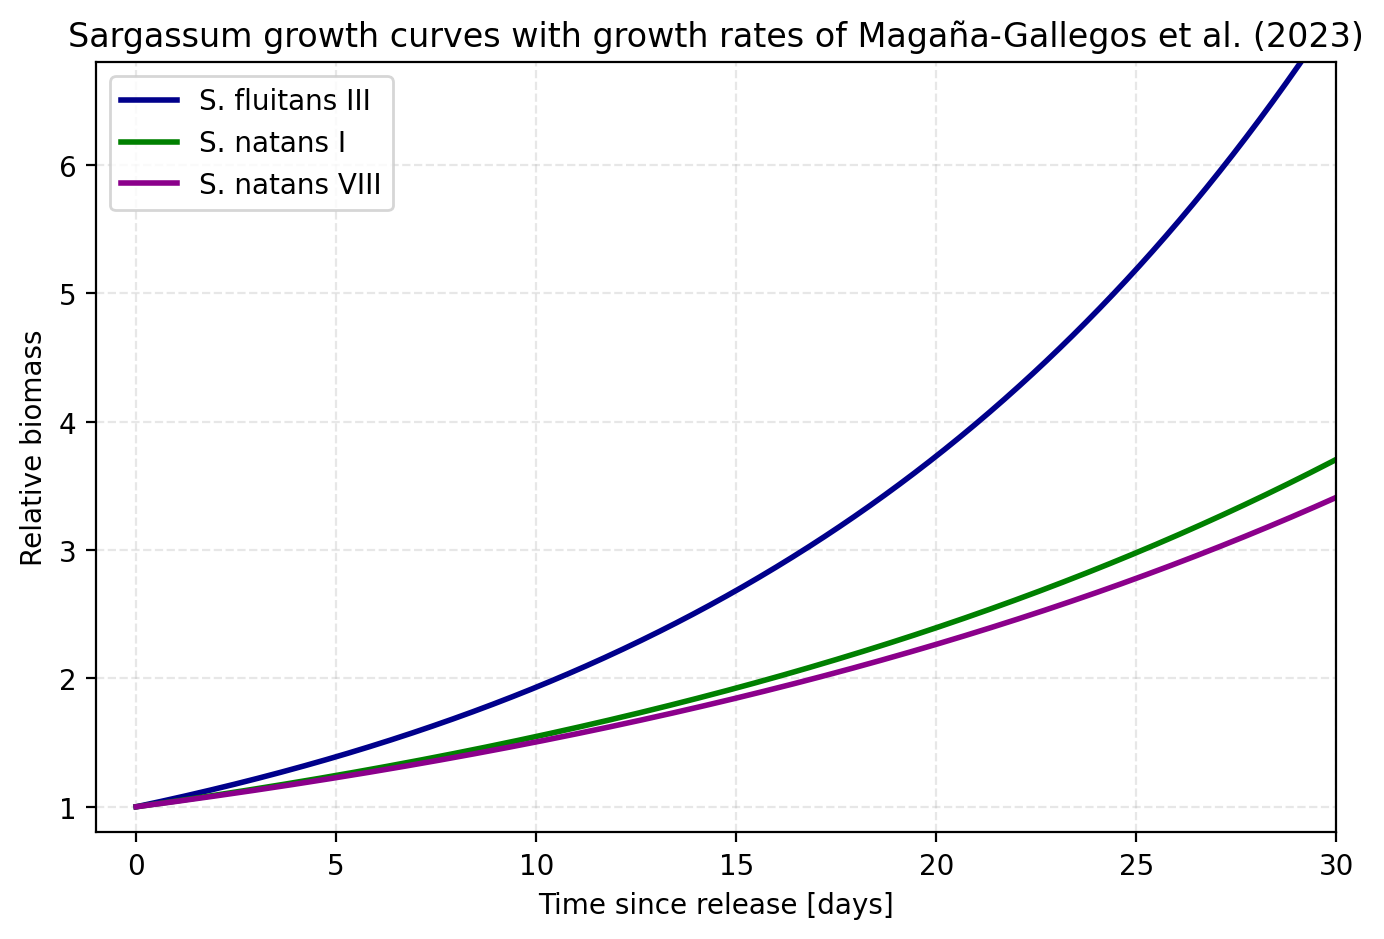

In [12]:
#Maximum growth rate measured by Magana-Gallegos et al. (2023)
MGR_SF3_MG = 0.095 #[Doubling/day]
MGR_SN8_MG = 0.059 #[Doubling/day]
MGR_SN1_MG = 0.063 #[Doubling/day]

#Maximum growth rate measured by Corbin & Oxenford (2023)
MGR_SF3_CO = 0.124
MGR_SN1_CO = 0.083
MGR_SN8_CO = 0.053


max_growth_rate_bonner = 0.00541
mortality = 0.02

rb_SF3 = 1
rb_SN8 = 1
rb_SN1 = 1

rb_SF3_CO = 1
rb_SN8_CO = 1
rb_SN1_CO = 1
ref_mort = 50
ref_bonner = 50

ref_time = np.arange(0,31,(1/24))
#Update particle weight with doubling rate converted from day-1 to s-1
limitation_factor = 1
rb_SF3 *= 2 ** (limitation_factor  *(MGR_SF3_MG  * ref_time ))
rb_SN8 *= 2 ** (limitation_factor * (MGR_SN8_MG  * ref_time ))
rb_SN1 *= 2 ** (limitation_factor * (MGR_SN1_MG * ref_time ))

rb_SF3_CO *= 2 ** (limitation_factor  *(MGR_SF3_CO  * ref_time ))
rb_SN8_CO *= 2 ** (limitation_factor * (MGR_SN8_CO  * ref_time ))
rb_SN1_CO *= 2 ** (limitation_factor * (MGR_SN1_CO * ref_time ))

ref_mort *= 2 ** (((limitation_factor * MGR_SF3_MG) - mortality )  * ref_time )

ref_bonner = ref_bonner + max_growth_rate_bonner * ref_time[:] * limitation_factor


figweightref = plt.figure(figsize = (8,5), dpi=200)
plt.plot(ref_time, rb_SF3 , '-', linewidth=2, c = 'darkblue', label = 'S. fluitans III')
plt.plot(ref_time, rb_SN1 , '-', linewidth=2, c = 'green', label = 'S. natans I')
plt.plot(ref_time, rb_SN8 , '-', linewidth=2, c = 'darkmagenta', label = 'S. natans VIII')

#plt.plot(ref_time, rb_SF3_CO , '--', c = 'darkblue', label = 'CO: S. fluitans III')
#plt.plot(ref_time, rb_SN1_CO , '--', c = 'green', label = 'CO: S. natans I')
#plt.plot(ref_time, rb_SN8_CO , '--', c = 'darkviolet', label = 'CO: S. natans VIII')

plt.title(f'Sargassum growth curves with growth rates of Magaña-Gallegos et al. (2023)', fontsize=12)
plt.xlabel('Time since release [days]')
plt.ylabel('Relative biomass')
plt.xlim(-1,30)
plt.ylim(0.8,6.8)
plt.legend()
plt.grid( linestyle='--', alpha=0.3)
plt.show()

[1.00000000e+00 9.99937695e-01 9.99750795e-01 9.99439346e-01
 9.99003427e-01 9.98443145e-01 9.97758641e-01 9.96950085e-01
 9.96017679e-01 9.94961655e-01 9.93782276e-01 9.92479836e-01
 9.91054660e-01 9.89507103e-01 9.87837550e-01 9.86046418e-01
 9.84134153e-01 9.82101231e-01 9.79948160e-01 9.77675476e-01
 9.75283745e-01 9.72773563e-01 9.70145556e-01 9.67400379e-01
 9.64538716e-01 9.61561281e-01 9.58468814e-01 9.55262088e-01
 9.51941900e-01 9.48509079e-01 9.44964481e-01 9.41308988e-01
 9.37543511e-01 9.33668990e-01 9.29686389e-01 9.25596701e-01
 9.21400945e-01 9.17100168e-01 9.12695441e-01 9.08187861e-01
 9.03578552e-01 8.98868663e-01 8.94059367e-01 8.89151864e-01
 8.84147376e-01 8.79047150e-01 8.73852458e-01 8.68564594e-01
 8.63184876e-01 8.57714644e-01 8.52155263e-01 8.46508117e-01
 8.40774614e-01 8.34956183e-01 8.29054274e-01 8.23070357e-01
 8.17005925e-01 8.10862488e-01 8.04641578e-01 7.98344744e-01
 7.91973557e-01 7.85529604e-01 7.79014491e-01 7.72429841e-01
 7.65777297e-01 7.590585

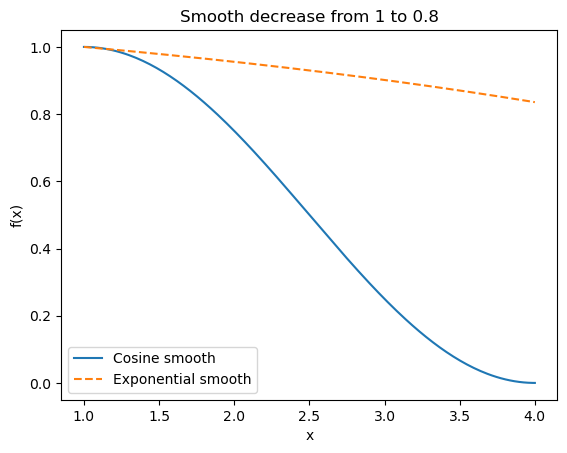

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def smooth_cos(x):
    return 0.5 + 0.5 * np.cos(np.pi * (x - 1) / 3)

def smooth_exp(x):
    return 1.2 - 0.2 * np.exp(0.2 * (x - 1))

x = np.linspace(1, 4, 200)

print(smooth_cos(x))
plt.plot(x, smooth_cos(x), label='Cosine smooth')
plt.plot(x, smooth_exp(x), label='Exponential smooth', linestyle='--')
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Smooth decrease from 1 to 0.8')
plt.show()

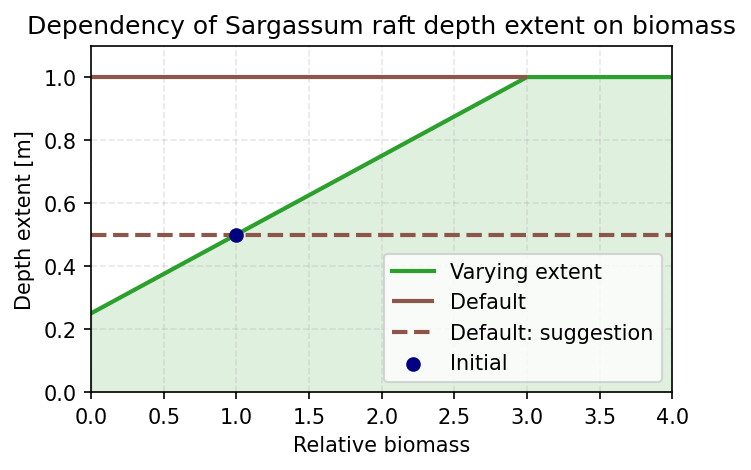

In [4]:
biomass = np.arange(0, 5.1, 0.1)
depth_extent = 0.25 + 0.25*biomass

for i in range(len(depth_extent)):
    if depth_extent[i] > 1:
        depth_extent[i] = 1

    
fig = plt.subplots(1, 1, figsize=(5, 3), dpi=150)

plt.fill_between(biomass, 0, depth_extent, alpha=0.15, color = 'tab:green')
plt.plot(biomass, depth_extent, label='Varying extent', color= 'tab:green', linewidth=2)
plt.hlines(1,0,3,color='tab:brown', label='Default', linewidth=2)
plt.hlines(0.5,0,5, color='tab:brown', label='Default: suggestion', linestyle ='--', linewidth=2)
plt.scatter(1, 0.5, label='Initial', color = 'navy', zorder=2)
plt.legend(loc='lower right')
plt.xlabel('Relative biomass')
plt.ylabel('Depth extent [m]')
plt.title('Dependency of Sargassum raft depth extent on biomass')
plt.xlim(0,4)
plt.ylim(0,1.1)
plt.grid(alpha=0.3, linestyle='--')
plt.show()

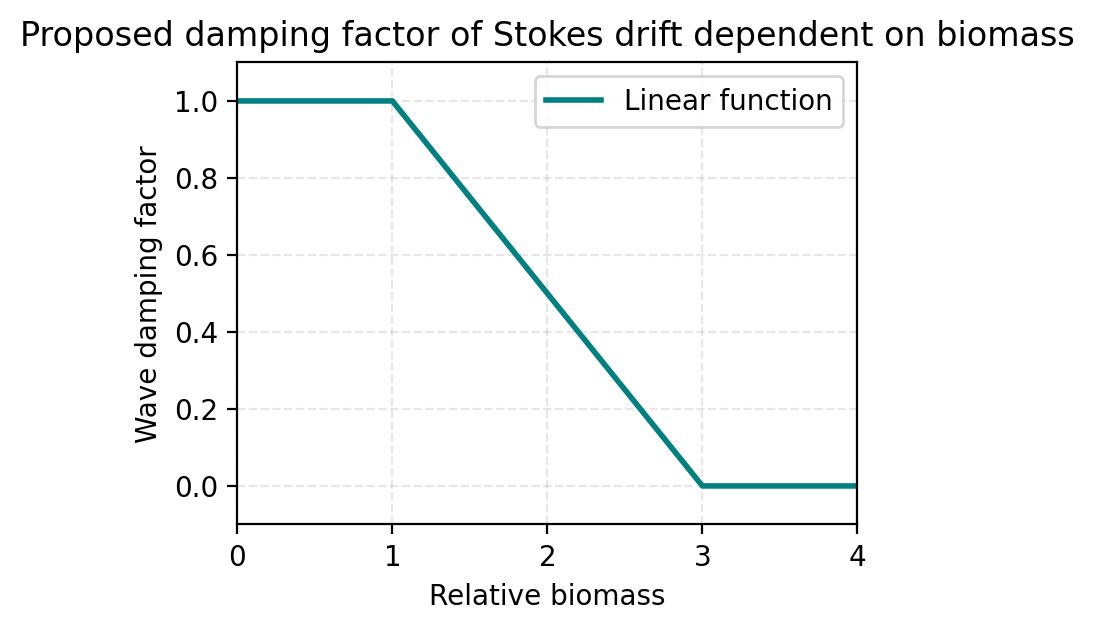

In [5]:
biomass = np.arange(0, 5.1, 0.1)

biomass_input = np.arange(0,4.1,0.1)

linear_wave_damping_factor  = 1.5 - 0.5*biomass_input

for i in range(len(biomass_input)):
    if biomass_input[i] < 1:
        linear_wave_damping_factor[i] = 1.0
    if biomass_input[i] > 3:
        linear_wave_damping_factor[i] = 0.0
    
fig = plt.subplots(1, 1, figsize=(4, 3), dpi=200)
plt.plot(biomass_input, linear_wave_damping_factor, label='Linear function', color= 'teal', linewidth=2)
#plt.plot(biomass, wave_damping(biomass), label='Cosine function', color= 'indianred', linewidth=2)
plt.legend(loc='upper right')
plt.xlabel('Relative biomass')
plt.ylabel('Wave damping factor')
plt.title('Proposed damping factor of Stokes drift dependent on biomass')
plt.xlim(0,4)
plt.ylim(-0.1,1.1)
plt.grid(alpha=0.3, linestyle='--')
plt.show()

In [10]:
#Try-out for CUSTOM_KERNELS:

biomass_input = 2.5

depth_extent = 0.25 + 0.25 * biomass_input

linear_wave_damping_factor = 1.5 - 0.5*biomass_input
if biomass_input < 1:
    linear_wave_damping_factor = 1.0
if biomass_input > 3:
    linear_wave_damping_factor = 0.0

print('depth extent: ', depth_extent)
print('wave damping: ', linear_wave_damping_factor)



depth extent:  0.875
wave damping:  0.25


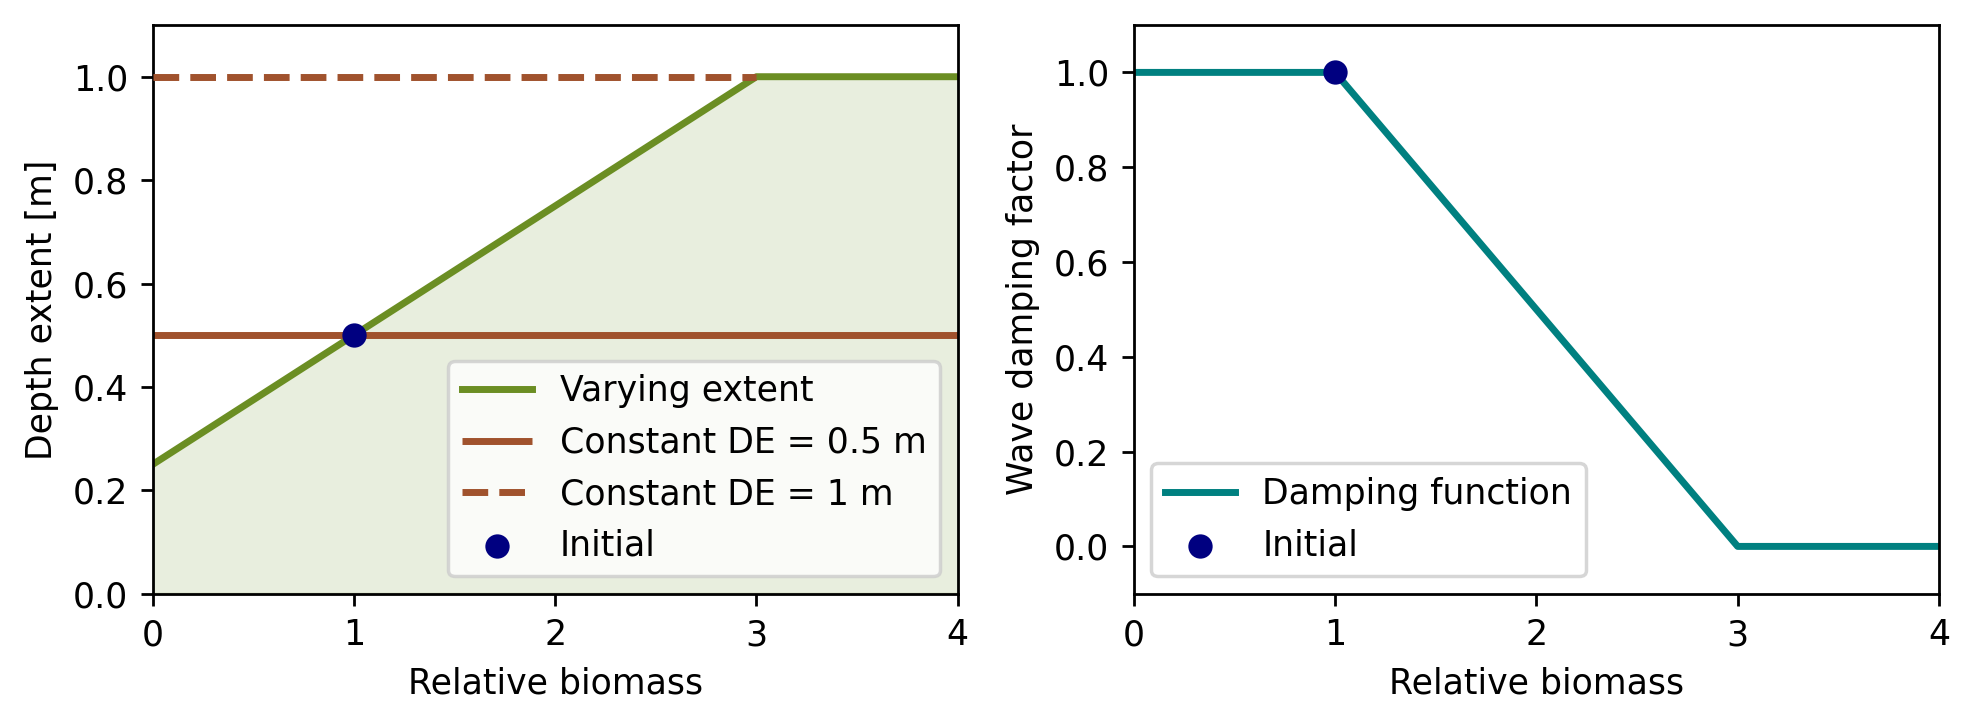

In [6]:

#Figure
fig_growthcurves, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3),dpi=250)

#Growth rate & mortality rate


ax1.plot(biomass, depth_extent, label='Varying extent', color= 'olivedrab', linewidth=2,zorder=2)
ax1.set_xlabel('Relative biomass')
ax1.set_ylabel('Depth extent [m]')
#ax1.set_title('Growth & mortality rate')
#ax1.grid(alpha=0.3, linestyle='--', axis='y')
ax1.fill_between(biomass, 0, depth_extent, alpha=0.15, color = 'olivedrab')
ax1.hlines(0.5,0,5, color='sienna', label='Constant DE = 0.5 m', linestyle ='-', linewidth=2)
ax1.hlines(1,0,3,color='sienna', label='Constant DE = 1 m',linestyle ='--', linewidth=2, zorder=7)
ax1.scatter(1, 0.5, label='Initial', color = 'navy', zorder=2)
ax1.legend(loc='lower right')
ax1.set_xlim(0,4)
ax1.set_ylim(0,1.1)
#plt.grid(alpha=0.3, linestyle='--')

#Temperature
ax2.plot(biomass_input, linear_wave_damping_factor, label='Damping function', color= 'teal', linewidth=2)
ax2.scatter(1, 1, label='Initial', color = 'navy', zorder=2)
ax2.set_xlabel('Relative biomass')
ax2.set_ylabel('Wave damping factor')
#ax2.set_title('Dependency on temperature')
#ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(loc='lower left')
ax2.set_xlim(0,4)
ax2.set_ylim(-0.1, 1.1)


plt.tight_layout()
plt.savefig("THESIS_PLOTS/physical_feedback_functions.pdf", format="pdf", bbox_inches="tight")
plt.savefig("THESIS_PLOTS/physical_feedback_functions.png", format="png", bbox_inches="tight")
plt.show()